# 05 — Analysis

Load the trained checkpoint, evaluate per-state prediction accuracy,
and compare the model's learned transition probabilities to the true
Gambler's Ruin matrix.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Load model & data

In [2]:
import sys

# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

In [3]:
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [4]:
checkpoint_path = DATA_DIR / "checkpoint.pt"
if not checkpoint_path.exists():
    candidates = sorted(DATA_DIR.glob("checkpoint_*.pt"))
    if not candidates:
        raise FileNotFoundError("No checkpoint found in data directory.")
    checkpoint_path = max(candidates, key=lambda p: p.stat().st_mtime)

ckpt = torch.load(checkpoint_path, weights_only=False)
cfg = ckpt["config"]
training_meta = ckpt.get("training", {})

model = MarkovTransformer(**cfg)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(
    f"Loaded {checkpoint_path.name} from epoch {ckpt['epoch']} "
    f"(val loss {ckpt['best_val_loss']:.4f})"
)

data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
Ts = data["Ts"]
pis = data["pis"]
seqs = data["sequences"]
chain_to_sample = data["chain_to_sample"]
data_cfg = data.get("config", {})

VOCAB = int(cfg["vocab_size"])
PAD_ID = int(data_cfg.get("pad_id", -1))

if Ts.shape[0] == 1:
    T_reference = Ts[0]
    pi_reference = pis[0]
else:
    chain_weights = torch.bincount(chain_to_sample, minlength=Ts.shape[0]).float()
    chain_weights = chain_weights / chain_weights.sum()
    T_reference = (chain_weights[:, None, None] * Ts).sum(dim=0)
    pi_reference = (chain_weights[:, None] * pis).sum(dim=0)

print(f"DGP regime: {data_cfg.get('dgp_regime', 'unknown')}")
print(f"Reference T shape: {tuple(T_reference.shape)}")

Loaded checkpoint_single_chain.pt from epoch 92 (val loss 1.2749)
DGP regime: single
Reference T shape: (5, 5)


## Training curve vs generalization loss

Load per-epoch checkpoints saved during training.  For each epoch, compute
the scalar generalization loss on a fixed held-out test set (same sequences
reused across epochs so the curve is comparable).  Plot together with the
training and validation loss curves and the Bayes-optimal NLL as a reference.

A well-trained model should show:
- Train ≈ Val ≈ Gen all converging toward Bayes NLL
- Gen loss slightly above Val loss (generalization gap)


Epoch checkpoints:   0%|          | 0/10 [00:00<?, ?ckpt/s]

Eval epoch 10:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 20:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 30:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 40:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Eval epoch 60:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 70:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 80:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 90:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 100:   0%|          | 0/1 [00:00<?, ?batch/s]

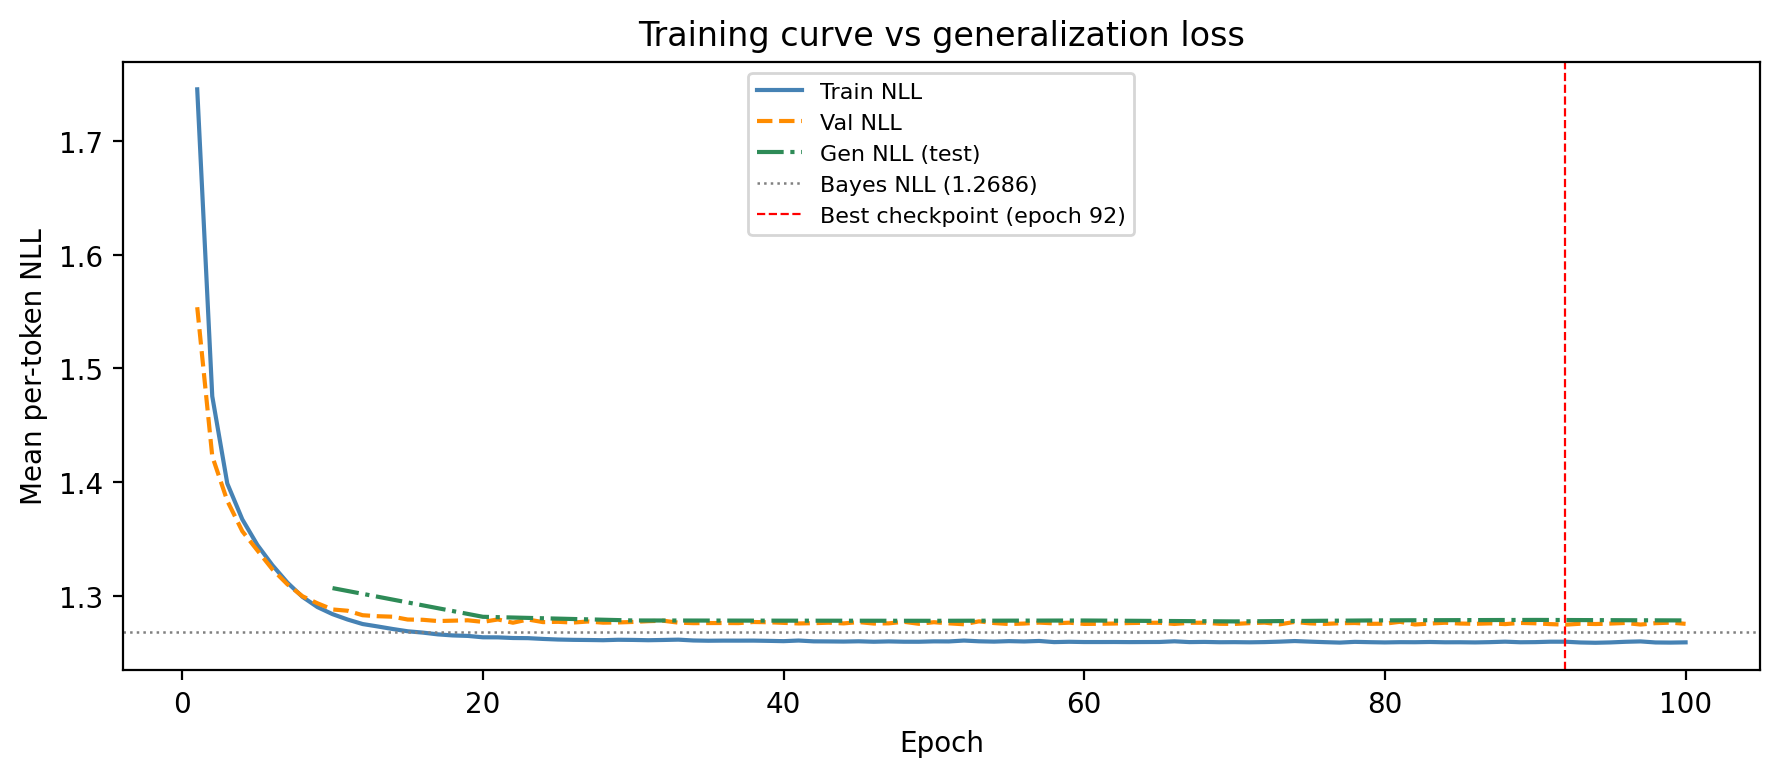

Final  train NLL : 1.259345
Final  val   NLL : 1.275614
Final  gen   NLL : 1.278609
Gen − Bayes gap  : 0.010002
Bayes-optimal NLL: 1.268606


In [5]:
import numpy as np
from markov_chain import sample_sequences
from tqdm.auto import tqdm

history_path = DATA_DIR / "training_history.pt"
checkpoints_dir = DATA_DIR / "checkpoints"

if not history_path.exists():
    print("No training_history.pt found — re-run 04_training.ipynb first.")
else:
    history = torch.load(history_path, weights_only=False)
    epochs = history["epochs"]
    train_losses = history["train_losses"]
    val_losses = history["val_losses"]

    # ── Fixed test set (reused across all epoch checkpoints) ─────────────────
    _max_len = int(data_cfg.get("seq_len", cfg.get("max_seq_len", 32)))
    _N = 100
    _rng = np.random.default_rng(0)
    _lengths = _rng.integers(low=2, high=_max_len + 1, size=_N)
    _seqs_np = sample_sequences(
        T_reference.numpy(),
        n=_N,
        seq_len=_max_len,
        prior=pi_reference.numpy(),
        rng=0,
    )
    _seqs = torch.from_numpy(_seqs_np).long()
    _x_in = _seqs[:, :-1]
    _x_tgt = _seqs[:, 1:]
    _valid = torch.arange(_max_len - 1) < (
        torch.from_numpy(_lengths).unsqueeze(1) - 1
    )  # (N, max_len-1)
    _log_T = torch.log(T_reference.clamp_min(1e-12))
    _valid_np = _valid.numpy()

    # Bayes NLL is model-independent — compute once
    _lpb = _log_T[_x_in, _x_tgt].float().numpy()
    bayes_nll = float(-_lpb[_valid_np].mean())

    # ── Loop over per-epoch checkpoints ──────────────────────────────────────
    ckpt_files = sorted(checkpoints_dir.glob("checkpoint_epoch_*.pt"))
    if not ckpt_files:
        print(f"No per-epoch checkpoints found in {checkpoints_dir}")
    else:
        gen_losses = []
        gen_epochs = []
        for ckpt_file in tqdm(ckpt_files, desc="Epoch checkpoints", unit="ckpt"):
            ep_ckpt = torch.load(ckpt_file, weights_only=False)
            ep = ep_ckpt["epoch"]

            ep_model = MarkovTransformer(**ep_ckpt["config"])
            ep_model.load_state_dict(ep_ckpt["model_state"])
            ep_model.eval()

            _lpm = torch.zeros(_N, _max_len - 1)
            with torch.no_grad():
                for start in tqdm(
                    range(0, _N, 512),
                    desc=f"Eval epoch {ep}",
                    unit="batch",
                    leave=False,
                ):
                    logits = ep_model(_x_in[start : start + 512])
                    lp = torch.log_softmax(logits, dim=-1)
                    tgt = _x_tgt[start : start + 512]
                    _lpm[start : start + 512] = lp.gather(
                        -1, tgt.unsqueeze(-1)
                    ).squeeze(-1)

            gen_nll = float(-_lpm.numpy()[_valid_np].mean())
            gen_losses.append(gen_nll)
            gen_epochs.append(ep)

        # ── Plot ─────────────────────────────────────────────────────────────
        best_epoch = ckpt["epoch"]

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(epochs, train_losses, label="Train NLL", color="steelblue")
        ax.plot(epochs, val_losses, label="Val NLL", color="darkorange", linestyle="--")
        ax.plot(
            gen_epochs,
            gen_losses,
            label="Gen NLL (test)",
            color="seagreen",
            linestyle="-.",
        )
        ax.axhline(
            bayes_nll,
            color="gray",
            linewidth=0.9,
            linestyle=":",
            label=f"Bayes NLL ({bayes_nll:.4f})",
        )
        ax.axvline(
            best_epoch,
            color="red",
            linewidth=0.8,
            linestyle="--",
            label=f"Best checkpoint (epoch {best_epoch})",
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean per-token NLL")
        ax.set_title("Training curve vs generalization loss")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        print(f"Final  train NLL : {train_losses[-1]:.6f}")

        print(f"Final  val   NLL : {val_losses[-1]:.6f}")

        print(f"Final  gen   NLL : {gen_losses[-1]:.6f}")
        print(f"Gen − Bayes gap  : {gen_losses[-1] - bayes_nll:.6f}")
        print(f"Bayes-optimal NLL: {bayes_nll:.6f}")

## Generalization loss vs sequence length

Sample `N` sequences with lengths drawn i.i.d. from
$l \sim \text{Uniform}\{2, \ldots, \text{max\_len}\}$.
Run the model on each; collect every valid per-step prediction as an
observation tagged with `(current_state, sequence_length)`.

Three diagnostics:

1. **NLL vs sequence length $l$** (line plot): mean per-token NLL across all
   positions within sequences of total length $l$.  Flat and close to the
   Bayes NLL = the model is length-invariant.

2. **Excess NLL heatmap** (state × $l$): for each (state, sequence-length)
   cell, mean excess NLL.  Should be uniformly near zero.

3. **Per-state excess** (bar chart): excess NLL marginalised over $l$.
   A spike at state $k$ means transitions *out of* $k$ were not learned
   uniformly across sequence lengths.


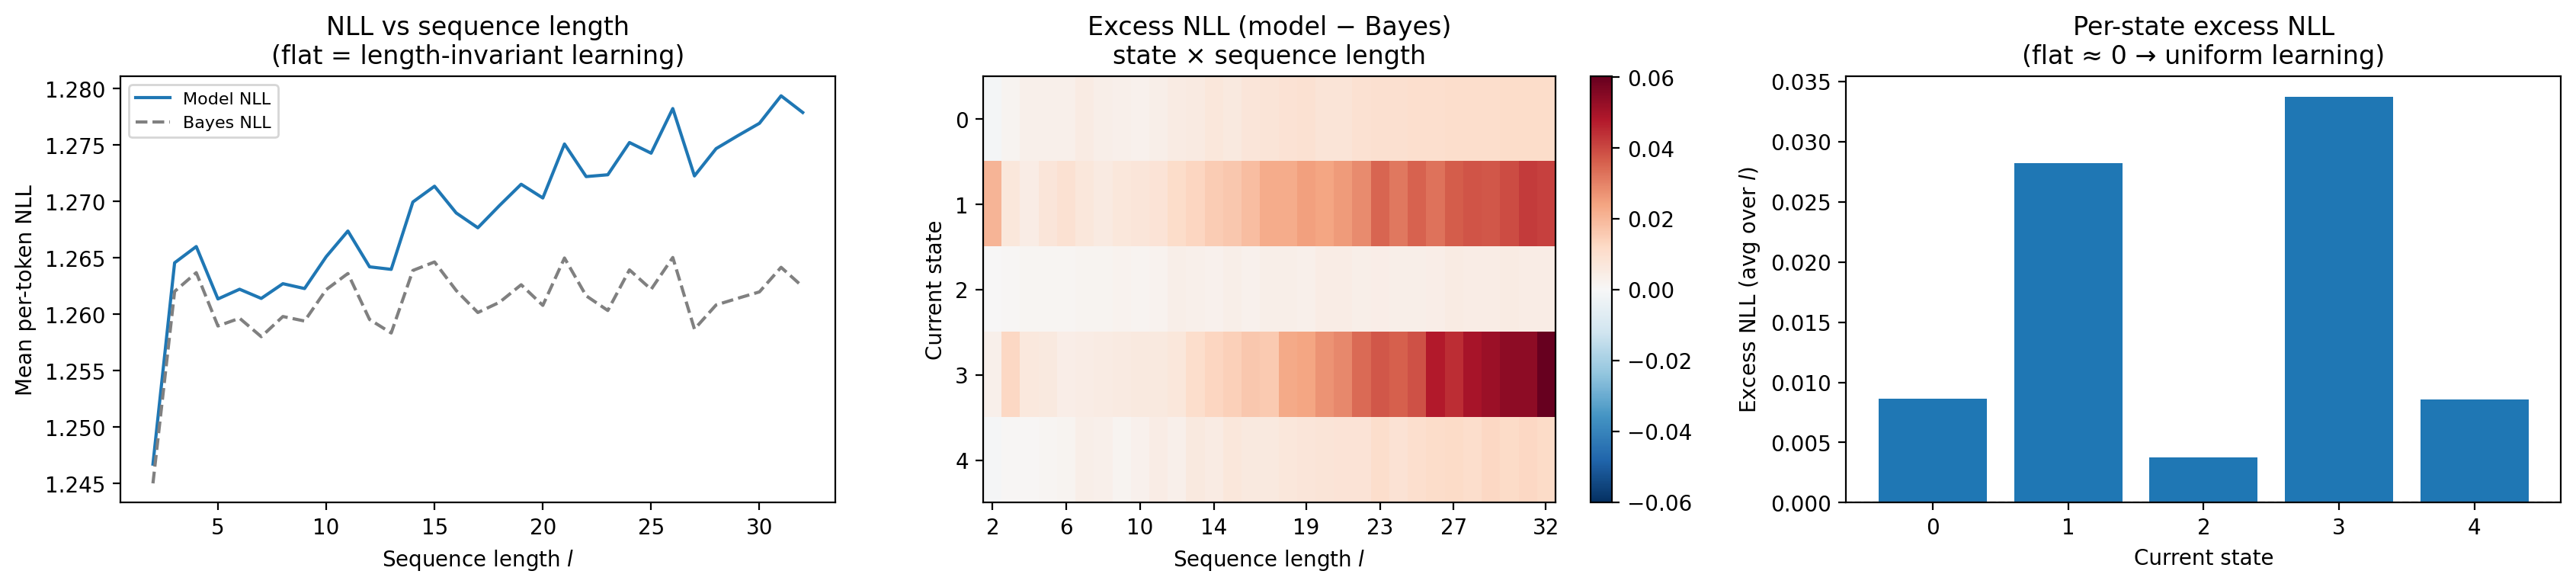

In [6]:
import numpy as np
from markov_chain import sample_sequences

max_len = int(data_cfg.get("seq_len", cfg.get("max_seq_len", 32)))
N_TEST = 250_000

# Draw sequence lengths i.i.d. from Uniform{2, ..., max_len}
rng_np = np.random.default_rng(42)
lengths = rng_np.integers(low=2, high=max_len + 1, size=N_TEST)  # (N,)

# Sample all sequences at max_len; the causal model means logits at position t
# only depend on x[0..t], so tokens beyond lengths[i]-1 are never "seen".
test_seqs_np = sample_sequences(
    T_reference.numpy(),
    n=N_TEST,
    seq_len=max_len,
    prior=pi_reference.numpy(),
    rng=42,
)
test_seqs = torch.from_numpy(test_seqs_np).long()  # (N, max_len)

x_in = test_seqs[:, :-1]  # (N, max_len-1)  context tokens
x_tgt = test_seqs[:, 1:]  # (N, max_len-1)  target tokens

# Position t (0-indexed) is valid for sequence i iff t+1 < lengths[i]
lengths_t = torch.from_numpy(lengths)
valid = torch.arange(max_len - 1) < (lengths_t.unsqueeze(1) - 1)  # (N, max_len-1)

# ── Model log-probs (full causal forward pass, then select valid entries) ─────
BATCH = 512
log_probs_model = torch.zeros(N_TEST, max_len - 1)
with torch.no_grad():
    for start in range(0, N_TEST, BATCH):
        logits = model(x_in[start : start + BATCH])
        lp = torch.log_softmax(logits, dim=-1)
        tgt = x_tgt[start : start + BATCH]
        log_probs_model[start : start + BATCH] = lp.gather(
            -1, tgt.unsqueeze(-1)
        ).squeeze(-1)

log_T = torch.log(T_reference.clamp_min(1e-12))
log_probs_bayes = log_T[x_in, x_tgt]  # (N, max_len-1)

# ── Flatten to per-observation arrays (only valid positions) ──────────────────
valid_np = valid.numpy()
flat_lpm = log_probs_model.numpy()[valid_np]  # model log-prob
flat_lpb = log_probs_bayes.float().numpy()[valid_np]  # Bayes log-prob
flat_state = x_in.numpy()[valid_np]  # current state
# sequence length for each observation
lengths_grid = np.tile(lengths[:, None], (1, max_len - 1))  # (N, max_len-1)
flat_len = lengths_grid[valid_np]  # in {2..max_len}

len_vals = np.arange(2, max_len + 1)

# ── 1. NLL vs sequence length ─────────────────────────────────────────────────
nll_model_by_l = np.array(
    [
        -flat_lpm[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)
nll_bayes_by_l = np.array(
    [
        -flat_lpb[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)

# ── 2. Per-(state, length) excess NLL heatmap ─────────────────────────────────
nll_st_model = np.full((VOCAB, len(len_vals)), np.nan)
nll_st_bayes = np.full((VOCAB, len(len_vals)), np.nan)

for li, l in enumerate(len_vals):
    mask_l = flat_len == l
    for s in range(VOCAB):
        mask_sl = mask_l & (flat_state == s)
        if mask_sl.any():
            nll_st_model[s, li] = -flat_lpm[mask_sl].mean()
            nll_st_bayes[s, li] = -flat_lpb[mask_sl].mean()

excess_st = nll_st_model - nll_st_bayes  # (VOCAB, len(len_vals))

# ── 3. Per-state excess, marginalising over length ────────────────────────────
excess_by_s = np.array(
    [
        -flat_lpm[flat_state == s].mean() + flat_lpb[flat_state == s].mean()
        if (flat_state == s).any()
        else np.nan
        for s in range(VOCAB)
    ]
)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Panel 1 — NLL vs sequence length
axes[0].plot(len_vals, nll_model_by_l, label="Model NLL")
axes[0].plot(len_vals, nll_bayes_by_l, linestyle="--", color="gray", label="Bayes NLL")
axes[0].set_xlabel("Sequence length $l$")
axes[0].set_ylabel("Mean per-token NLL")
axes[0].set_title("NLL vs sequence length\n(flat = length-invariant learning)")
axes[0].legend(fontsize=8)

# Panel 2 — Excess NLL heatmap (state × length)
vmax = float(np.nanmax(np.abs(excess_st))) or 1.0
tick_idx = np.linspace(0, len(len_vals) - 1, min(8, len(len_vals)), dtype=int)
im = axes[1].imshow(excess_st, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels(len_vals[tick_idx])
axes[1].set_yticks(range(VOCAB))
axes[1].set_xlabel("Sequence length $l$")
axes[1].set_ylabel("Current state")
axes[1].set_title("Excess NLL (model − Bayes)\nstate × sequence length")
plt.colorbar(im, ax=axes[1])

# Panel 3 — Per-state excess, length marginalised
axes[2].bar(range(VOCAB), excess_by_s)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_xticks(range(VOCAB))
axes[2].set_xlabel("Current state")
axes[2].set_ylabel("Excess NLL (avg over $l$)")
axes[2].set_title("Per-state excess NLL\n(flat ≈ 0 → uniform learning)")

plt.tight_layout()
plt.show()

Recompute KL per checkpoint:   0%|          | 0/10 [00:00<?, ?ckpt/s]

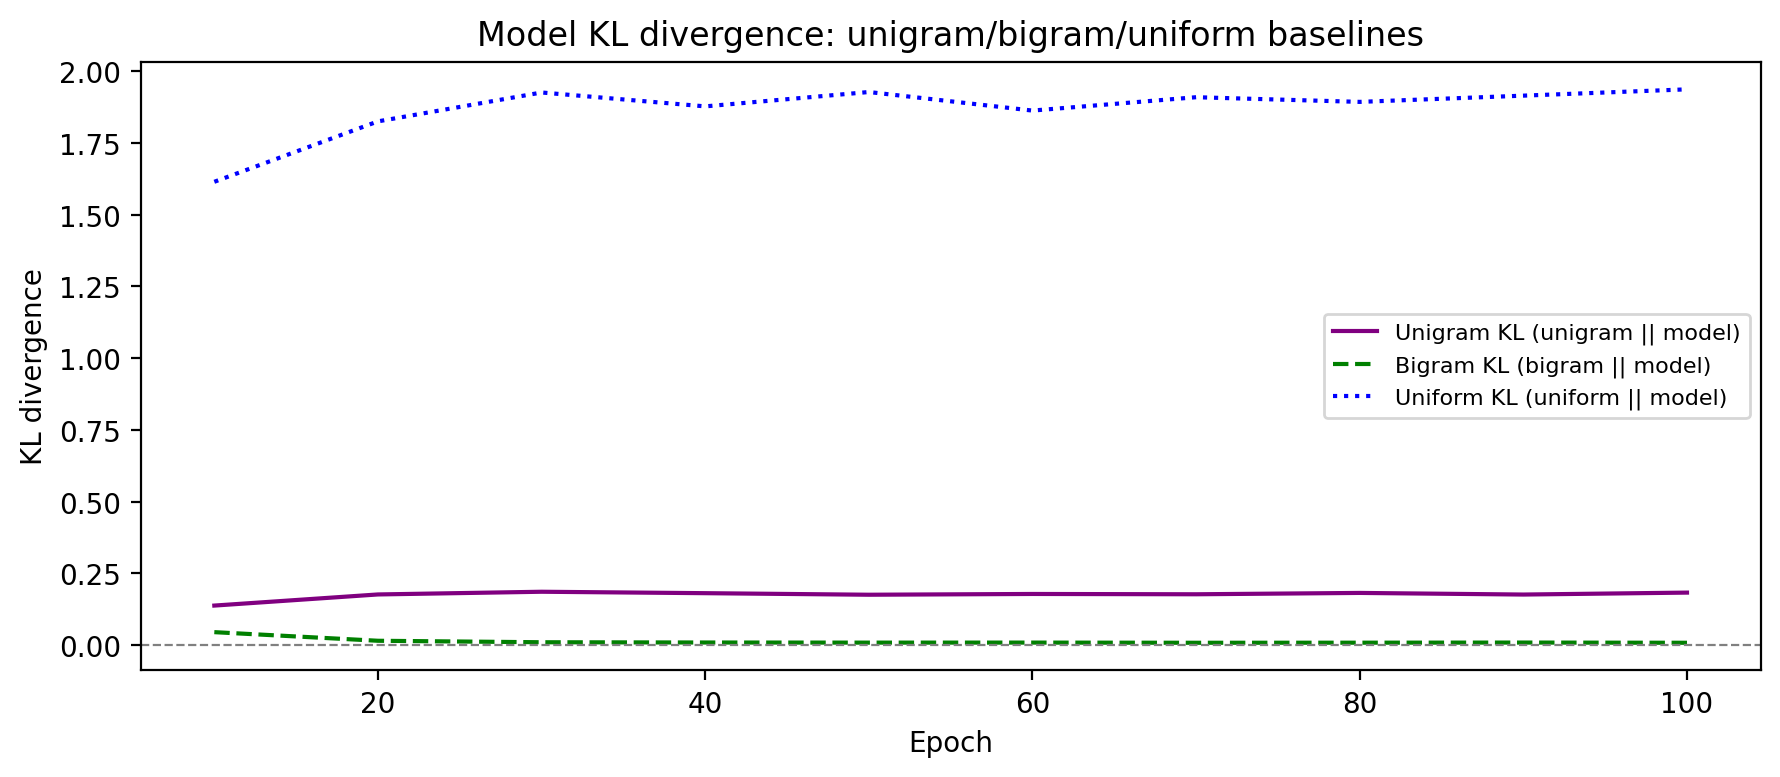

Final unigram KL: 0.183387
Final bigram KL: 0.008625
Final uniform KL: 1.936645


In [7]:
# --- Additional analysis: KL divergence from unigram (stationary) baseline ---
# compute gen_kl_unigram from scratch using checkpoint models
from tqdm.auto import tqdm

pi = torch.from_numpy(pi_reference.numpy()).float()
log_pi = torch.log(pi.clamp_min(1e-12))

ckpt_files = sorted(checkpoints_dir.glob("checkpoint_epoch_*.pt"))
if not ckpt_files:
    raise FileNotFoundError(f"No per-epoch checkpoints found in {checkpoints_dir}")

gen_epochs = []
gen_kl_unigram = []
gen_kl_bigram = []
gen_kl_uniform = []

uniform_prob = 1.0 / float(VOCAB)
log_uniform = torch.log(torch.tensor(uniform_prob, dtype=torch.float32))

for ckpt_file in tqdm(ckpt_files, desc="Recompute KL per checkpoint", unit="ckpt"):
    ep_ckpt = torch.load(ckpt_file, weights_only=False)
    ep = ep_ckpt["epoch"]

    ep_model = MarkovTransformer(**ep_ckpt["config"])
    ep_model.load_state_dict(ep_ckpt["model_state"])
    ep_model.eval()

    kl_uni_sum = 0.0
    kl_bi_sum = 0.0
    kl_uni_sum_uniform = 0.0
    kl_count = 0

    with torch.no_grad():
        for start in range(0, _N, 512):
            logits = ep_model(_x_in[start : start + 512])
            probs = torch.softmax(logits, dim=-1)

            # Unigram baseline KL(unigram || model)
            kl_uni = (
                pi[None, None, :]
                * (log_pi[None, None, :] - torch.log(probs.clamp_min(1e-12)))
            ).sum(dim=-1)

            # Bigram baseline KL(bigram || model), based on true transition rows
            p_bigram = T_reference[_x_in[start : start + 512]]
            log_p_bigram = torch.log(p_bigram.clamp_min(1e-12))
            kl_bi = (p_bigram * (log_p_bigram - torch.log(probs.clamp_min(1e-12)))).sum(
                dim=-1
            )

            valid_batch = _valid[start : start + 512]
            kl_uni_sum += float(kl_uni[valid_batch].sum().item())
            kl_bi_sum += float(kl_bi[valid_batch].sum().item())

            # Uniform baseline KL(uniform || model)
            kl_uniform = log_uniform - torch.log(probs.clamp_min(1e-12))
            kl_uniform = kl_uniform.sum(dim=-1)
            kl_uni_sum_uniform += float(kl_uniform[valid_batch].sum().item())

            kl_count += int(valid_batch.sum().item())

    gen_epochs.append(ep)
    gen_kl_unigram.append(float(kl_uni_sum / max(1, kl_count)))
    gen_kl_bigram.append(float(kl_bi_sum / max(1, kl_count)))
    gen_kl_uniform.append(float(kl_uni_sum_uniform / max(1, kl_count)))

fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(
    gen_epochs,
    gen_kl_unigram,
    label="Unigram KL (unigram || model)",
    color="purple",
    linestyle="-",
)
ax3.plot(
    gen_epochs,
    gen_kl_bigram,
    label="Bigram KL (bigram || model)",
    color="green",
    linestyle="--",
)
ax3.plot(
    gen_epochs,
    gen_kl_uniform,
    label="Uniform KL (uniform || model)",
    color="blue",
    linestyle=":",
)
ax3.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax3.set_xlabel("Epoch")
ax3.set_ylabel("KL divergence")
ax3.set_title("Model KL divergence: unigram/bigram/uniform baselines")
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Final unigram KL: {gen_kl_unigram[-1]:.6f}")
print(f"Final bigram KL: {gen_kl_bigram[-1]:.6f}")
print(f"Final uniform KL: {gen_kl_uniform[-1]:.6f}")

## Posterior Sampling

In [8]:
# Prepare data for BayesianNet
x_data = seqs[:, :-1]
y_data = seqs[:, 1:]
# Replace PAD_ID with 0 in x_data to avoid one_hot error
x_data = x_data.clone()
x_data[x_data == PAD_ID] = 0

In [9]:
def loss_fn(logits, targets):
    ce = F.cross_entropy(
        logits.reshape(-1, VOCAB),
        targets.reshape(-1),
        reduction="none",
        ignore_index=PAD_ID,
    )
    ce = ce.view(logits.shape[:-1])
    mask = (targets != PAD_ID).float()
    return (ce * mask).sum() / mask.sum()


sigma = 10.0


def make_prior_logp(map_vec: torch.Tensor):
    """Gaussian prior N(map_vec, sigma^2 I) — centred at the MAP."""
    mean = map_vec.detach().clone()

    def prior_logp(params):
        flat = torch.cat([p.flatten() for p in params])
        diff = flat - mean
        return -0.5 * diff.pow(2).sum() / (sigma**2)

    return prior_logp

## Multi-trial Hessian & Sampling Stability Analysis

Train the model 3 times independently (different random seeds), compute Hessian at each MAP, sample from each, and compare 2D projections across trials to assess stability of our Hessian-based sampling approach.


In [20]:
import numpy as np
import torch
import torch.optim as optim
from torch.func import hessian
from tqdm.auto import tqdm

# ──────────────────────────────────────────────────────────────────────────────
# 1. Train 3 independent models with different random seeds
# ──────────────────────────────────────────────────────────────────────────────

trials = {}
seeds = [42, 123, 456]
epochs_to_train = 50  # Increased for better convergence

print("=" * 80)
print("Training 3 independent models...")
print("=" * 80)

for trial_id, seed in enumerate(seeds):
    print(f"\n[Trial {trial_id + 1}/3] Training with seed={seed}")

    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Create fresh model
    trial_model = MarkovTransformer(**cfg)
    trial_model.train()

    optimizer = optim.Adam(trial_model.parameters(), lr=cfg.get("lr", 1e-3))
    batch_size = 128  # increase batch size for more stable gradients
    train_dataset = torch.utils.data.TensorDataset(x_data, y_data)
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    # Quick training on same data
    train_losses_trial = []

    for epoch in range(epochs_to_train):
        epoch_loss = 0.0
        count = 0

        for xb, yb in train_loader:
            with torch.enable_grad():
                logits = trial_model(xb)
                loss = loss_fn(logits, yb)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * xb.shape[0]
                count += xb.shape[0]

        epoch_loss = epoch_loss / max(1, count)
        train_losses_trial.append(epoch_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch + 1:3d}/{epochs_to_train} — Loss: {epoch_loss:.6f}")

    trial_model.eval()

    # Store trial data
    trials[trial_id] = {
        "seed": seed,
        "model": trial_model,
        "map_params": torch.cat(
            [p.flatten() for p in trial_model.parameters()]
        ).detach(),
        "train_losses": train_losses_trial,
    }

    print(f"  Final loss: {train_losses_trial[-1]:.6f}")

print("\n" + "=" * 80)
print("Training complete. Extracting MAP and computing Hessians...")
print("=" * 80)

Training 3 independent models...

[Trial 1/3] Training with seed=42
  Epoch   5/50 — Loss: 1.371946
  Epoch  10/50 — Loss: 1.302925
  Epoch  15/50 — Loss: 1.279972
  Epoch  20/50 — Loss: 1.271426
  Epoch  25/50 — Loss: 1.266919
  Epoch  30/50 — Loss: 1.265233
  Epoch  35/50 — Loss: 1.263909
  Epoch  40/50 — Loss: 1.263101
  Epoch  45/50 — Loss: 1.262244
  Epoch  50/50 — Loss: 1.261989
  Final loss: 1.261989

[Trial 2/3] Training with seed=123
  Epoch   5/50 — Loss: 1.365015
  Epoch  10/50 — Loss: 1.304724
  Epoch  15/50 — Loss: 1.279503
  Epoch  20/50 — Loss: 1.268207
  Epoch  25/50 — Loss: 1.264975
  Epoch  30/50 — Loss: 1.262630
  Epoch  35/50 — Loss: 1.262735
  Epoch  40/50 — Loss: 1.262133
  Epoch  45/50 — Loss: 1.262026
  Epoch  50/50 — Loss: 1.261063
  Final loss: 1.261063

[Trial 3/3] Training with seed=456
  Epoch   5/50 — Loss: 1.335533
  Epoch  10/50 — Loss: 1.289201
  Epoch  15/50 — Loss: 1.273821
  Epoch  20/50 — Loss: 1.268169
  Epoch  25/50 — Loss: 1.265185
  Epoch  30/50

In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# 2. Compute Hessian at each MAP
# ──────────────────────────────────────────────────────────────────────────────


def compute_hessian_at_map(model, loss_fn, x_data, y_data, valid):
    """
    Compute approximate Hessian of loss at the current model parameters.
    Returns eigenvalues and eigenvectors.
    """
    model.eval()

    # Use approximate Hessian from torch_bdn for efficiency (now with chunking)
    from torch_bdn.bn.bayesian_net import approx_hessian

    H = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240)

    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = torch.linalg.eigh(H)

    return eigvals, eigvecs, H


print("\nComputing Hessians at each MAP...")
for trial_id in sorted(trials.keys()):
    print(f"  Trial {trial_id + 1}: ", end="", flush=True)
    model = trials[trial_id]["model"]

    try:
        eigvals, eigvecs, H = compute_hessian_at_map(
            model, loss_fn, x_data, y_data, valid
        )

        trials[trial_id]["eigvals"] = eigvals
        trials[trial_id]["eigvecs"] = eigvecs
        trials[trial_id]["hessian"] = H

        print(f"✓ (λ_min={eigvals[0]:.2e}, λ_max={eigvals[-1]:.2e})")
    except Exception as e:
        print(f"✗ Error: {e}")


Computing Hessians at each MAP...
  Trial 1: ✓ (λ_min=-4.83e-02, λ_max=5.45e+00)
  Trial 2: ✓ (λ_min=-9.17e-02, λ_max=8.14e+00)
  Trial 3: ✓ (λ_min=-6.51e-02, λ_max=8.33e+00)


In [ ]:
print("\nSampling from each trial's posterior...")
for trial_id in sorted(trials.keys()):
    print(f"  Trial {trial_id + 1}: ", end="", flush=True)

    trial_model = trials[trial_id]["model"]
    trial_prior_logp = make_prior_logp(trials[trial_id]["map_params"])

    bn_trial = BayesianNet(trial_model, loss_fn, trial_prior_logp)
    sampler_trial = Sampler(bn_trial, x_data, y_data)

    try:
        samples_trial = sampler_trial.sample(
            config=NUTS(n_warmup=1000, step_size=0.1, max_tree_depth=5),
            n_samples=1000,
            n_chains=2,
            swap_every=0,
            init_strategy=Prior(),
        )

        chain_trial = torch.stack(samples_trial.flat_parameters()).cpu().numpy()
        trials[trial_id]["samples"] = samples_trial
        trials[trial_id]["chain"] = chain_trial

        print(f"✓ ({chain_trial.shape[0]} samples)")
    except Exception as e:
        print(f"✗ Error: {e}")


Sampling from each trial's posterior...
  Trial 1: ✓ (2000 samples)
  Trial 2: ✓ (2000 samples)
  Trial 3: ✓ (2000 samples)


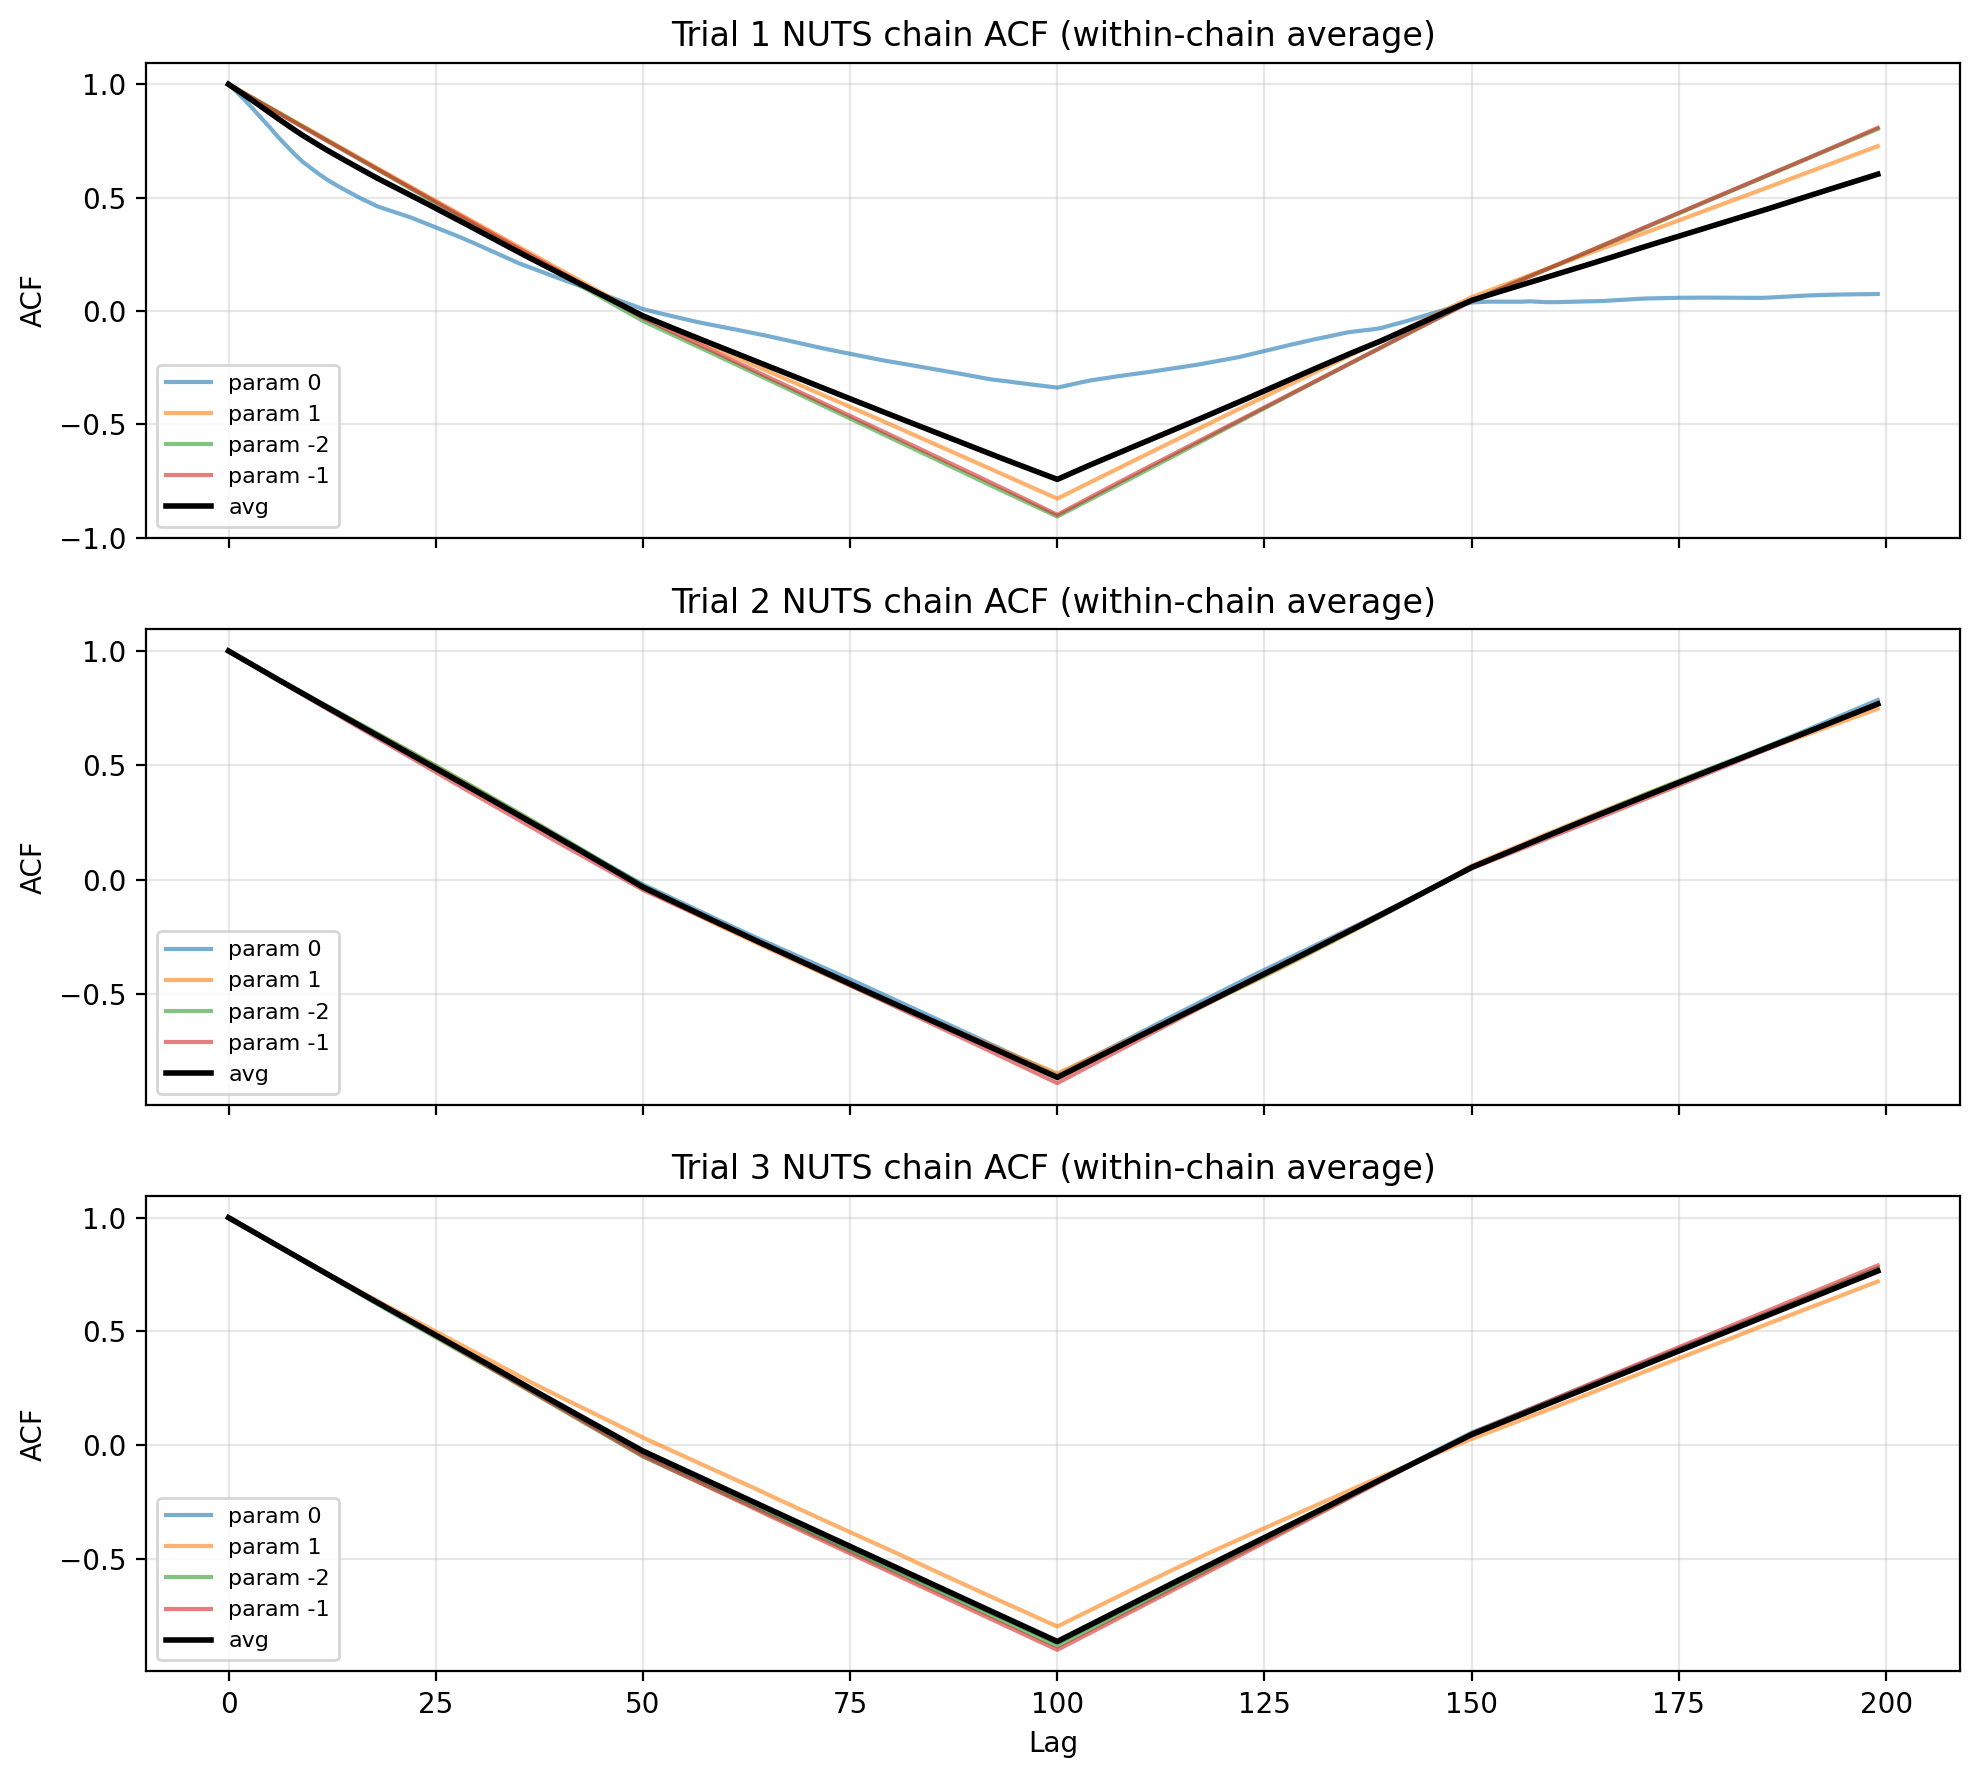

In [28]:
# Plot ACF per chain, then average across chains.
# Flattening multiple chains into one series creates artificial jumps at chain boundaries.
import matplotlib.pyplot as plt
import numpy as np

selected_idx = [0, 1, -2, -1]  # first two and last two params (adjust as needed)
max_lag = 200
n_trials = len(trials)

fig, axes = plt.subplots(n_trials, 1, figsize=(10, 3 * n_trials), sharex=True)
if n_trials == 1:
    axes = [axes]

for row, trial_id in enumerate(sorted(trials.keys())):
    chain_stacked = trials[trial_id]["samples"].stacked().cpu().numpy()  # (C, S, D)
    acs = []

    for idx in selected_idx:
        per_chain_acfs = []
        for chain_idx in range(chain_stacked.shape[0]):
            x = chain_stacked[chain_idx, :, idx]
            x = x - x.mean()
            ac = np.correlate(x, x, mode="full")
            ac = ac[ac.size // 2 :]
            ac = ac / max(ac[0], 1e-12)
            per_chain_acfs.append(ac[:max_lag])
        acs.append(np.mean(per_chain_acfs, axis=0))

    acs = np.stack(acs, axis=0)
    avg_acf = acs.mean(axis=0)

    ax = axes[row]
    for i, idx in enumerate(selected_idx):
        ax.plot(acs[i], label=f"param {idx}", alpha=0.6)
    ax.plot(avg_acf, label="avg", color="black", lw=2)
    ax.set_title(f"Trial {row + 1} NUTS chain ACF (within-chain average)")
    ax.set_ylabel("ACF")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Lag")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

trial_ids = sorted(trials.keys())
n_trials = len(trial_ids)
palette = sns.color_palette("tab10", n_trials)

fig, axes = plt.subplots(n_trials, n_trials, figsize=(5 * n_trials, 4 * n_trials))
fig.suptitle(
    "Posterior samples projected onto Hessian eigenvectors\n"
    "rows = sample trial, cols = Hessian basis trial",
    fontsize=13,
)

for row, sample_id in enumerate(trial_ids):
    chain = trials[sample_id]["chain"]
    map_params = trials[sample_id]["map_params"].detach().cpu().numpy()
    centered = chain - map_params

    for col, hessian_id in enumerate(trial_ids):
        eigvecs = trials[hessian_id]["eigvecs"]
        eigvals = trials[hessian_id]["eigvals"]
        u_min = eigvecs[:, 0].cpu().numpy()
        u_max = eigvecs[:, -1].cpu().numpy()

        ax = axes[row, col]
        ax.scatter(
            centered @ u_min,
            centered @ u_max,
            alpha=0.35,
            s=6,
            color=palette[sample_id],
            rasterized=True,
        )
        ax.set_xlabel(f"$u_{{\\min}}$ ($\\lambda$={eigvals[0]:.1e})", fontsize=9)
        ax.set_ylabel(f"$u_{{\\max}}$ ($\\lambda$={eigvals[-1]:.1e})", fontsize=9)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.2)
        if row == 0:
            ax.set_title(
                f"Hessian: Trial {hessian_id + 1}", fontsize=10, fontweight="bold"
            )
        if col == 0:
            ax.set_ylabel(
                f"Trial {sample_id + 1} samples\n$u_{{\\max}}$ ($\\lambda$={eigvals[-1]:.1e})",
                fontsize=9,
            )

plt.tight_layout()
plt.show()

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 5. Summary statistics: Hessian stability analysis
# ──────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("HESSIAN STABILITY ANALYSIS")
print("=" * 80)

# Collect eigenvalue statistics
eigenvalue_stats = {}
for trial_id in sorted(trials.keys()):
    eigvals = trials[trial_id]["eigvals"].cpu().numpy()
    eigenvalue_stats[trial_id] = {
        "min": eigvals[0],
        "max": eigvals[-1],
        "median": np.median(eigvals),
        "ratio": eigvals[-1] / max(eigvals[0], 1e-10),
        "condition_number": np.linalg.cond(trials[trial_id]["hessian"].cpu().numpy()),
    }

print("\nEigenvalue statistics for each trial:")
print(
    f"{'Trial':<10} {'λ_min':<15} {'λ_max':<15} {'λ_max/λ_min':<15} {'Condition #':<15}"
)
print("-" * 70)
for trial_id in sorted(trials.keys()):
    stats = eigenvalue_stats[trial_id]
    print(
        f"Trial {trial_id + 1:<4} {stats['min']:<15.2e} {stats['max']:<15.2e} "
        f"{stats['ratio']:<15.1f} {stats['condition_number']:<15.1e}"
    )

# Compute elongation ratios from samples
print("\n" + "-" * 70)
print("Elongation ratios in sample projections:")
print(
    f"{'Sample Trial':<20} {'onto Trial 1 Hessian':<25} {'onto Trial 2 Hessian':<25} {'onto Trial 3 Hessian':<25}"
)
print("-" * 95)

for sample_trial_id in sorted(trials.keys()):
    chain = trials[sample_trial_id]["chain"]
    map_params = trials[sample_trial_id]["map_params"].detach().cpu().numpy()
    centered = chain - map_params.reshape(1, -1)

    print(f"Trial {sample_trial_id + 1:<17}", end="")

    for hessian_trial_id in sorted(trials.keys()):
        eigvecs = trials[hessian_trial_id]["eigvecs"]
        u_smallest = eigvecs[:, 0].cpu().numpy()
        u_largest = eigvecs[:, -1].cpu().numpy()

        coord_smallest = centered @ u_smallest
        coord_largest = centered @ u_largest

        spread_smallest = np.std(coord_smallest)
        spread_largest = np.std(coord_largest)
        ratio = max(spread_smallest, spread_largest) / (
            min(spread_smallest, spread_largest) + 1e-10
        )

        print(f"{ratio:<25.2f}", end="")
    print()

print("\n" + "=" * 80)
print("Interpretation:")
print("  ✓ If condition number & elongation ratios are similar across trials →")
print("    Hessian structure is stable, sampling setup is reliable")
print("  ✗ If they vary significantly →")
print("    Different MAPs have different curvatures, revisit model/data")
print("=" * 80)

In [ ]:
import numpy as np

# Stack all samples (should already exclude burn-in from sampler)
chain_full = torch.stack(samples["parameters"]).cpu().numpy()  # (n, D)

# Optional: discard additional initial samples as extra safety margin
additional_burn_in = 100  # additional samples to skip
chain = chain_full[additional_burn_in:, :]

print(f"Chain shape after burn-in removal: {chain.shape}")
print(f"(discarded first {additional_burn_in} of {chain_full.shape[0]} samples)")

# Plot autocorrelation for selected parameters
fig, ax = plt.subplots(figsize=(10, 5))
for idx in np.random.choice(910, size=10, replace=False):
    x = chain[:, idx] - chain[:, idx].mean()
    ac = np.correlate(x, x, mode="full")
    ac = ac[ac.size // 2 :]  # take positive lags
    ac = ac / ac[0]  # normalize by lag-0 (variance), not by global max
    ax.plot(ac[:500], label=f"param {idx}")
ax.legend()
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation function (after burn-in removal)")
plt.tight_layout()
plt.show()

In [ ]:
# Compute integrated autocorrelation time (IACT) and average ACF across selected parameters
selected_idx = [0, 1, 908, 909]
max_lag = 500
acs = []
taus = []
for idx in selected_idx:
    x = chain[:, idx] - chain[:, idx].mean()
    ac = np.correlate(x, x, mode="full")
    ac = ac[ac.size // 2 :]
    ac = ac / ac[0]
    acs.append(ac[:max_lag])

    # Standard IACT estimate by summing until first negative lag
    tau = 1.0
    for t in range(1, len(ac)):
        if ac[t] <= 0:
            break
        tau += 2.0 * ac[t]
    taus.append(tau)

acs = np.stack(acs, axis=0)
avg_acf = acs.mean(axis=0)

print("Selected parameters:", selected_idx)
for idx, tau in zip(selected_idx, taus):
    print(f"param {idx}: integrated autocorrelation time ≈ {tau:.2f}")
print(f"Average IACT across selected params: {np.mean(taus):.2f}")

# Plot average ACF across selected parameters
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_acf[:200], lw=2)
ax.set_xlabel("Lag")
ax.set_ylabel("Average ACF")
ax.set_title("Average autocorrelation function across selected parameters")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also compute average ACF across all parameters for a more global view
# using the same IACT cutoff rule on each dimension and average
all_acs = []
all_taus = []
for idx in selected_idx:
    all_acs.append(acs[selected_idx.index(idx)])
    all_taus.append(taus[selected_idx.index(idx)])

print(f"Average ACF at lag 1: {avg_acf[1]:.3f}")
print(f"Average ACF at lag 10: {avg_acf[10]:.3f}")
print(f"Average ACF at lag 50: {avg_acf[50]:.3f}")
print(f"Average ACF at lag 100: {avg_acf[100]:.3f}")

In [ ]:
from torch import linalg
from torch_bdn.bn.bayesian_net import approx_hessian

ckpt = torch.load(checkpoint_path, weights_only=False)
bn.model.load_state_dict(ckpt["model_state"])
bn.model.eval()

H = approx_hessian(bn.model, bn.loss_fn, x_data, y_data)
eigvals, eigvecs = linalg.eigh(H)  # ascending order
# bottom-k eigenvectors = eigvecs[:, :k]

In [ ]:
# Find the index where eigenvalues become positive
pos_mask = eigvals > 0
first_pos_idx = pos_mask.nonzero()[0].item()  # smallest positive eigenvalue index
print(
    f"Smallest positive eigenvalue: {eigvals[first_pos_idx].item():.4e} at index {first_pos_idx}"
)

# Pick bottom-two smallest-magnitude eigenvectors
u1 = eigvecs[:, first_pos_idx]
u2 = eigvecs[:, first_pos_idx + 1]

In [ ]:
from torch.nn.utils import parameters_to_vector

# 2. Extract eigenvectors for largest and smallest eigenvalues
u_largest = eigvecs[:, -1]  # eigenvector corresponding to largest eigenvalue
u_smallest = eigvecs[:, 0]  # eigenvector corresponding to smallest eigenvalue
print(f"Using eigenvalues λ_min={eigvals[0]:.2e}, λ_max={eigvals[-1]:.2e}")

# 3. Center samples around the MAP
chain_full_tensor = torch.from_numpy(chain_full).float()  # shape (n_samples, d)
map_params = parameters_to_vector(bn.model.parameters()).detach()  # shape (d,)
centered = chain_full_tensor - map_params.unsqueeze(0)  # shape (n_samples, d)

# 4. Build orthonormal basis matrix A = [u_smallest, u_largest] and projection matrix P = A A^T
A = torch.stack([u_smallest, u_largest], dim=1)  # shape (d, 2)
P = A @ A.T  # projection matrix, shape (d, d)

# 5. Project each sample: x_proj = P @ (x - MAP)
projections = centered @ P.T  # shape (n_samples, d)

# 6. Extract 2D coordinates in the {u_smallest, u_largest} basis
coord_smallest = centered @ u_smallest  # scalar position along u_smallest
coord_largest = centered @ u_largest  # scalar position along u_largest

# 7. Verify: reconstruct from coordinates
reconstructed = coord_smallest.unsqueeze(1) * u_smallest.unsqueeze(
    0
) + coord_largest.unsqueeze(1) * u_largest.unsqueeze(0)
# This should match the projection
recon_error = (reconstructed - projections).norm(dim=1).mean()
print(f"Reconstruction error (should be ~0): {recon_error.item():.2e}")

# 8. Visualize in 2D coordinates
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    coord_smallest.cpu().numpy(),
    coord_largest.cpu().numpy(),
    alpha=0.4,
    s=8,
    c=coord_largest.cpu().numpy(),
    cmap="viridis",
)
ax.set_xlabel("Projection onto u_min (smallest eigenvalue direction)")
ax.set_ylabel("Projection onto u_max (largest eigenvalue direction)")
ax.set_title(
    "SGLD posterior samples: lowest-curvature vs highest-curvature directions\n(spanned by {{u_min, u_max}})"
)
ax.grid(True, alpha=0.2)
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Coord (largest)")
plt.tight_layout()
plt.show()

# Diagnose: check elongation
spread_smallest = coord_smallest.std().item()
spread_largest = coord_largest.std().item()
ratio = max(spread_smallest, spread_largest) / (
    min(spread_smallest, spread_largest) + 1e-8
)
print(f"Spread along u_min (lowest curvature): {spread_smallest:.4f}")
print(f"Spread along u_max (highest curvature): {spread_largest:.4f}")
print(f"Elongation ratio: {ratio:.2f}x")

# Samples should be centered near MAP (since SGLD started from MAP)
centered = chain_full_tensor - map_params.unsqueeze(0)
print(f"Mean sample distance from MAP: {centered.norm(dim=1).mean().item():.4f}")
print(f"Max sample distance from MAP: {centered.norm(dim=1).max().item():.4f}")

In [ ]:
# Extract parameters for pair plot from flattened samples
import pandas as pd

# Inspect available model parameter names
print("model parameters:", [name for name, _ in model.named_parameters()])

# Choose a small subset of parameters for quick pair-plot visualization.
# Here we use first two elements of the first (input projection) and last (output projection)
# parameter tensors as a minimal representative 4D metric.
param_names = [name for name, _ in model.named_parameters()]

# Convert the flattened sample set to actual model states for feature extraction.
embed_vals = []
output_vals = []
# each sample is a flattened vector
for param_vec in samples["parameters"]:
    bn.set_parameters(param_vec)
    # replace these with real parameter names appropriate to your model.
    p_in = model.input_proj.weight.flatten()[0:2].detach().cpu().numpy()
    p_out = model.head.weight.flatten()[0:2].detach().cpu().numpy()
    embed_vals.append(p_in)
    output_vals.append(p_out)

n = len(embed_vals)
assert len(output_vals) == n

pair_data = pd.DataFrame(
    {
        "input_proj_0": [v[0] for v in embed_vals],
        "input_proj_1": [v[1] for v in embed_vals],
        "output_0": [v[0] for v in output_vals],
        "output_1": [v[1] for v in output_vals],
    }
)

sns.pairplot(
    pair_data,
    corner=True,
    diag_kind="kde",
    markers="o",
    plot_kws={"alpha": 0.5, "s": 2},
)
plt.suptitle("SGLD posterior pair plot (selected weights)", y=1.02)
plt.show()

In [ ]:
print("BayesianNet structure:")
print(bn)
print("\nModel inside BayesianNet:")
print(bn.model)
print("\nModel parameters summary:")
for name, param in bn.model.named_parameters():
    print(f"{name}: {param.shape}")

In [ ]:
# Plot ACF per chain (then averaged across chains) for each trial.
# Flattening chains creates artificial jumps at chain boundaries, so we
# compute the ACF separately per chain and average — same as the NUTS cell.
import matplotlib.pyplot as plt
import numpy as np

selected_idx = [0, 1, -2, -1]
max_lag = 200
n_trials = len(trials)

fig, axes = plt.subplots(n_trials, 1, figsize=(10, 3 * n_trials), sharex=True)
if n_trials == 1:
    axes = [axes]

for row, trial_id in enumerate(sorted(trials.keys())):
    chain_stacked = trials[trial_id]["samples"].stacked().cpu().numpy()  # (C, S, D)
    acs = []

    for idx in selected_idx:
        per_chain_acfs = []
        for chain_idx in range(chain_stacked.shape[0]):
            x = chain_stacked[chain_idx, :, idx]
            x = x - x.mean()
            ac = np.correlate(x, x, mode="full")
            ac = ac[ac.size // 2 :]
            ac = ac / max(ac[0], 1e-12)
            per_chain_acfs.append(ac[:max_lag])
        acs.append(np.mean(per_chain_acfs, axis=0))

    acs = np.stack(acs, axis=0)
    avg_acf = acs.mean(axis=0)

    ax = axes[row]
    for i, idx in enumerate(selected_idx):
        ax.plot(acs[i], label=f"param {idx}", alpha=0.6)
    ax.plot(avg_acf, label="avg", color="black", lw=2)
    ax.set_title(f"Trial {row + 1} SGLD chain ACF (within-chain average)")
    ax.set_ylabel("ACF")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Lag")
plt.tight_layout()
plt.show()

In [ ]:
# Pairwise projections of SGLD samples onto Hessian eigenvectors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# For each trial, project samples onto its own Hessian eigenvectors (first 4 directions)
proj_dim = 4  # number of eigen-directions to use
records = []
for trial_id in sorted(trials.keys()):
    chain = trials[trial_id]["chain"]
    eigvecs = trials[trial_id]["eigvecs"]
    # Project onto first proj_dim eigenvectors
    for i in range(proj_dim):
        for j in range(i + 1, proj_dim):
            proj_i = chain @ eigvecs[:, i].cpu().numpy()
            proj_j = chain @ eigvecs[:, j].cpu().numpy()
            for k in range(len(proj_i)):
                records.append(
                    {
                        "proj_i": proj_i[k],
                        "proj_j": proj_j[k],
                        "eig_i": f"eig_{i}",
                        "eig_j": f"eig_{j}",
                        "trial": f"Trial {trial_id + 1}",
                    }
                )

proj_df = pd.DataFrame(records)

# Plot: columns = (eig_i, eig_j) pairs, rows = trial, hue = trial
pair_labels = proj_df.groupby(["eig_i", "eig_j"]).ngroup().values
proj_df["pair"] = proj_df["eig_i"] + " vs " + proj_df["eig_j"]

# Get all unique pairs
pairs = (
    proj_df[["eig_i", "eig_j", "pair"]]
    .drop_duplicates()
    .sort_values(["eig_i", "eig_j"])
    .reset_index(drop=True)
)

n_pairs = len(pairs)
n_trials = proj_df["trial"].nunique()

fig, axes = plt.subplots(
    n_trials, n_pairs, figsize=(4 * n_pairs, 4 * n_trials), sharex=False, sharey=False
)
if n_trials == 1:
    axes = [axes]
if n_pairs == 1:
    axes = [[ax] for ax in axes]

for row, trial in enumerate(sorted(proj_df["trial"].unique())):
    trial_df = proj_df[proj_df["trial"] == trial]
    for col, (eig_i, eig_j, pair) in pairs.itertuples(index=False):
        ax = axes[row][col]
        # Plot all trials as hue
        sns.scatterplot(
            data=proj_df[proj_df["pair"] == pair],
            x="proj_i",
            y="proj_j",
            hue="trial",
            alpha=0.3,
            s=8,
            ax=ax,
            legend=(row == 0 and col == 0),
        )
        ax.set_title(f"{pair}")
        if col == 0:
            ax.set_ylabel(trial)
        else:
            ax.set_ylabel("")
        if row == n_trials - 1:
            ax.set_xlabel(pair)
        else:
            ax.set_xlabel("")
        ax.grid(True, alpha=0.2)
        ax.set_aspect("equal")
if n_trials * n_pairs > 1:
    plt.tight_layout()
plt.show()

In [ ]:
# For each trial, plot a pairplot (corner plot) of SGLD samples projected onto the first k Hessian eigenvectors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

proj_dim = 4  # number of eigen-directions to use
for trial_id in sorted(trials.keys()):
    chain = trials[trial_id]["chain"]
    eigvecs = trials[trial_id]["eigvecs"]
    # Project onto first proj_dim eigenvectors
    projections = {}
    for i in range(proj_dim):
        projections[f"eig_{i}"] = chain @ eigvecs[:, i].cpu().numpy()
    df_proj = pd.DataFrame(projections)
    # Pairplot: all pairs and marginals
    g = sns.pairplot(
        df_proj, corner=True, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8}
    )
    g.fig.suptitle(
        f"Trial {trial_id + 1}: Posterior projections onto first {proj_dim} Hessian eigenvectors",
        y=1.02,
    )
    plt.show()

In [ ]:
# Increase the number of eigen-directions to visualize more low-curvature (small eigenvalue) directions
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

proj_dim = 8  # increase to 8 or more to see more low-curvature directions
for trial_id in sorted(trials.keys()):
    chain = trials[trial_id]["chain"]
    eigvecs = trials[trial_id]["eigvecs"]
    # Project onto first proj_dim eigenvectors (smallest eigenvalues)
    projections = {}
    for i in range(proj_dim):
        projections[f"eig_{i}"] = chain @ eigvecs[:, i].cpu().numpy()
    df_proj = pd.DataFrame(projections)
    # Pairplot: all pairs and marginals
    g = sns.pairplot(
        df_proj, corner=True, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8}
    )
    g.fig.suptitle(
        f"Trial {trial_id + 1}: Posterior projections onto first {proj_dim} Hessian eigenvectors (smallest eigenvalues)",
        y=1.02,
    )
    plt.show()